In [10]:
import sys
sys.path.append('../src')

In [11]:
import numpy as np
from data_generator import build_cholesky_factor, sample_functions, compute_antiderivative
import matplotlib.pyplot as plt

In [12]:
n_fine = 100
ell = .5
rng= np.random.default_rng(40)
x_fine = np.linspace(0, 1, n_fine)

In [13]:
L = build_cholesky_factor(x_fine, ell)
u = sample_functions(L, 100, rng)

In [14]:
integral = compute_antiderivative(u = u, x_fine=x_fine)

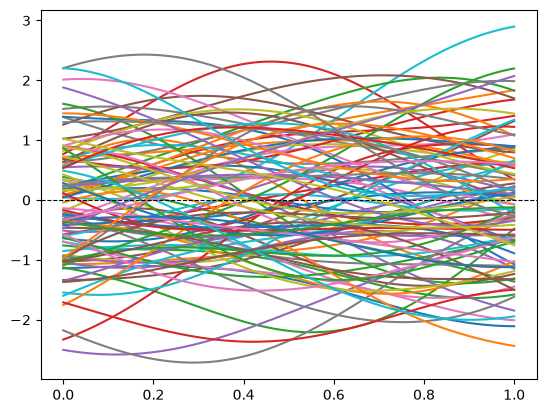

In [15]:
for i in range(u.shape[0]):
    plt.plot(x_fine, u[i])
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

In [16]:
from model import DeepONet
from sklearn.model_selection import train_test_split

In [17]:
u_train, u_test, s_train, s_test = train_test_split(u, integral)

u_small = u_train[:10,]
s_small = s_train[:10,]

y_query = x_fine.reshape(-1,1)


In [18]:
model = DeepONet(n_fine)
model.train()

DeepONet(
  (branch): Sequential(
    (0): Linear(in_features=100, out_features=40, bias=True)
    (1): Tanh()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): Tanh()
    (4): Linear(in_features=40, out_features=40, bias=True)
  )
  (trunk): Sequential(
    (0): Linear(in_features=1, out_features=40, bias=True)
    (1): Tanh()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): Tanh()
    (4): Linear(in_features=40, out_features=40, bias=True)
    (5): Tanh()
  )
)

## Training

In [19]:
import torch

u_small_t = torch.tensor(u_small, dtype=torch.float32)
s_small_t = torch.tensor(s_small, dtype=torch.float32)
y_query_t = torch.tensor(y_query, dtype=torch.float32)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

In [20]:
n_epochs = 2000
losses = []

for epoch in range(n_epochs):
    optimizer.zero_grad()
    pred = model(u_small_t, y_query_t)
    loss = loss_fn(pred, s_small_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 200 == 0:
        print(f"epoch {epoch:4d}  loss {loss.item():.6f}")

epoch    0  loss 0.231415
epoch  200  loss 0.001461
epoch  400  loss 0.000299
epoch  600  loss 0.000273
epoch  800  loss 0.000242
epoch 1000  loss 0.000220
epoch 1200  loss 0.000202
epoch 1400  loss 0.000165
epoch 1600  loss 0.000145
epoch 1800  loss 0.000119


Text(0, 0.5, 'MSE loss')

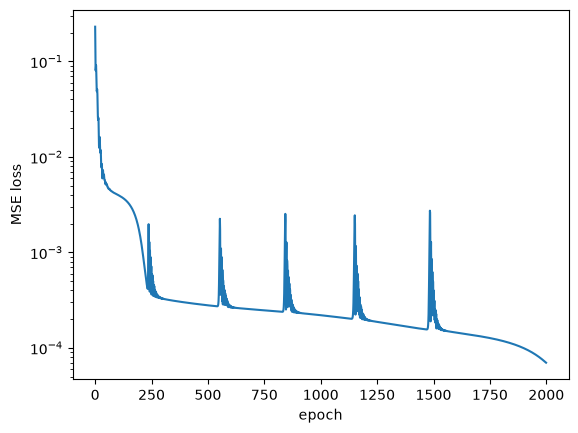

In [21]:
plt.plot(losses)
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('MSE loss')

## Evaluate on held-out functions

test MSE: 0.006988


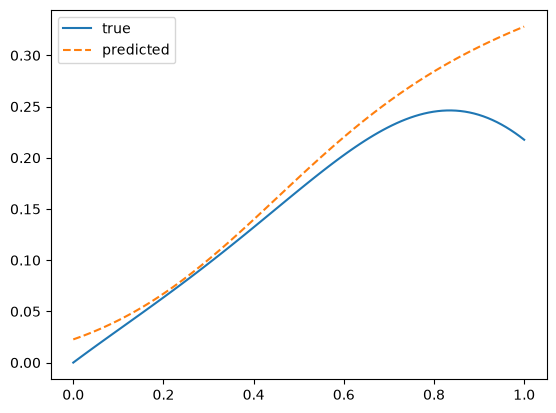

In [22]:
model.eval()
u_test_t = torch.tensor(u_test, dtype=torch.float32)
s_test_t = torch.tensor(s_test, dtype=torch.float32)

with torch.no_grad():
    pred_test = model(u_test_t, y_query_t)
    test_loss = loss_fn(pred_test, s_test_t)

print(f"test MSE: {test_loss.item():.6f}")

i = 0
plt.plot(x_fine, s_test[i], label='true')
plt.plot(x_fine, pred_test[i].numpy(), '--', label='predicted')
plt.legend()